# Module 1 — Deep Models: Convolutional Neural Networks
## From Pixels to ConvNets — A Hands-On PyTorch Tutorial
**Applied AI Mastery Program** | Rina Buoy, PhD

---

| Section | Topic | Slides |
|---------|-------|--------|
| §1 | Why not just flatten? | 5–7 |
| §2 | The convolution operation | 8–17 |
| §3 | Multi-channel inputs, padding & stride | 18–22 |
| §4 | Non-linearity (ReLU) & pooling | 23–24 |
| §5 | Multi-filter volumes — manual vs. `nn.Conv2d` | 25 |
| §6 | Counting parameters & FLOPs | 26–27 |
| §7 | Transposed convolution (deconvolution) | 28 |
| §8 | Building & training a full ConvNet | 29 |
| §9 | Normalization layers | 30–31 |
| §10 | Modern architectures — VGG, ResNet, init | 32–36 |
| §11 | Training recipe — preprocessing, augmentation, transfer learning, hyperparameters | 37–45 |
| §12 | CNN applications — detection, segmentation, autoencoders | 46–54 |

> Each section opens with the slide numbers it reproduces, then builds the idea in code.


In [59]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models

from skimage import data as skdata

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('mps' if torch.backends.mps.is_available()
                       else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('Using device:', device)


Using device: mps


---
## §1  Why Not Just Flatten? (Slides 5–7)
> A tabular model computes $\hat y = f(x_1,\dots,x_m)$ on a flat feature vector. Slides 5–7 show that
> images and text get the *same* treatment in a plain MLP: flatten to a vector, feed a perceptron.
> The problem: flattening throws away the 2D neighborhood structure — pixel (i,j) has no special
> relationship to its neighbors once everything is a 1D vector.


In [60]:
# Slide 6 — flattening a 2D input into a vector for an MLP
grid = np.array([[1, 1, 0],
                  [4, 2, 1],
                  [0, 2, 1]])

print('2D input (h=3, w=3):')
print(grid)
print('\nFlattened vector fed to a perceptron:')
print(grid.flatten())

# Two images that are neighborhoods apart in pixel space can end up
# far apart in the flattened vector, and vice versa — an MLP's first-layer
# weights must independently learn every pixel position from scratch.
shifted = np.roll(grid, shift=1, axis=1)
print('\nA 1-pixel horizontal shift changes the *entire* flattened vector:')
print('original :', grid.flatten())
print('shifted  :', shifted.flatten())


2D input (h=3, w=3):
[[1 1 0]
 [4 2 1]
 [0 2 1]]

Flattened vector fed to a perceptron:
[1 1 0 4 2 1 0 2 1]

A 1-pixel horizontal shift changes the *entire* flattened vector:
original : [1 1 0 4 2 1 0 2 1]
shifted  : [0 1 1 1 4 2 1 0 2]


---
## §2  The Convolution Operation (Slides 8–17)
> Instead of connecting every pixel to every neuron, a **filter** slides over the image and computes
> a **Hadamard product + sum** at every position (slides 9–14). This is the convolution operation
> (slide 15). Let's build it from scratch with `numpy`, then verify against `torch`.


In [61]:
# Slide 10 — Hadamard product (element-wise multiply)
A = np.array([[1, 2, 8], [5, 0, 8]])
B = np.array([[5, 3, 3], [2, 7, 1]])
print('A ⊙ B =\n', A * B)


A ⊙ B =
 [[ 5  6 24]
 [10  0  8]]


In [62]:
# Slides 11–15 — sliding a 3x3 filter over a 5x5 binary input, one neuron per position
def conv2d_manual(x, w, stride=1, padding=0):
    # Valid/padded 2D convolution (no channels), reproduces slides 11-20.
    if padding > 0:
        x = np.pad(x, padding)
    H, W = x.shape
    kH, kW = w.shape
    out_h = (H - kH) // stride + 1
    out_w = (W - kW) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            patch = x[i*stride:i*stride+kH, j*stride:j*stride+kW]
            out[i, j] = np.sum(patch * w)          # Hadamard product + sum
    return out

x = np.array([[1, 1, 1, 0, 0],
              [0, 1, 1, 1, 0],
              [0, 0, 1, 1, 1],
              [0, 0, 1, 1, 0],
              [0, 1, 1, 0, 0]], dtype=float)

w = np.array([[1, 0, 1],
              [0, 1, 0],
              [1, 0, 1]], dtype=float)

feature_map = conv2d_manual(x, w)
print('Input (5x5):\n', x)
print('\nFilter (3x3):\n', w)
print('\nFeature map (3x3) — should match slide 15 exactly [[4,3,4],[2,4,3],[2,3,4]]:')
print(feature_map)


Input (5x5):
 [[1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 0.]
 [0. 1. 1. 0. 0.]]

Filter (3x3):
 [[1. 0. 1.]
 [0. 1. 0.]
 [1. 0. 1.]]

Feature map (3x3) — should match slide 15 exactly [[4,3,4],[2,4,3],[2,3,4]]:
[[4. 3. 4.]
 [2. 4. 3.]
 [2. 3. 4.]]


In [63]:
# Cross-check the manual implementation against torch.nn.functional.conv2d
x_t = torch.tensor(x).view(1, 1, 5, 5)          # (N, C, H, W)
w_t = torch.tensor(w).view(1, 1, 3, 3)          # (out_ch, in_ch, kH, kW)

torch_out = F.conv2d(x_t, w_t, bias=None, stride=1, padding=0)
print('torch.nn.functional.conv2d output:\n', torch_out.squeeze().numpy())
assert np.allclose(feature_map, torch_out.squeeze().numpy())
print('\n✓ Manual convolution matches PyTorch exactly.')


torch.nn.functional.conv2d output:
 [[4. 3. 4.]
 [2. 4. 3.]
 [2. 3. 4.]]

✓ Manual convolution matches PyTorch exactly.


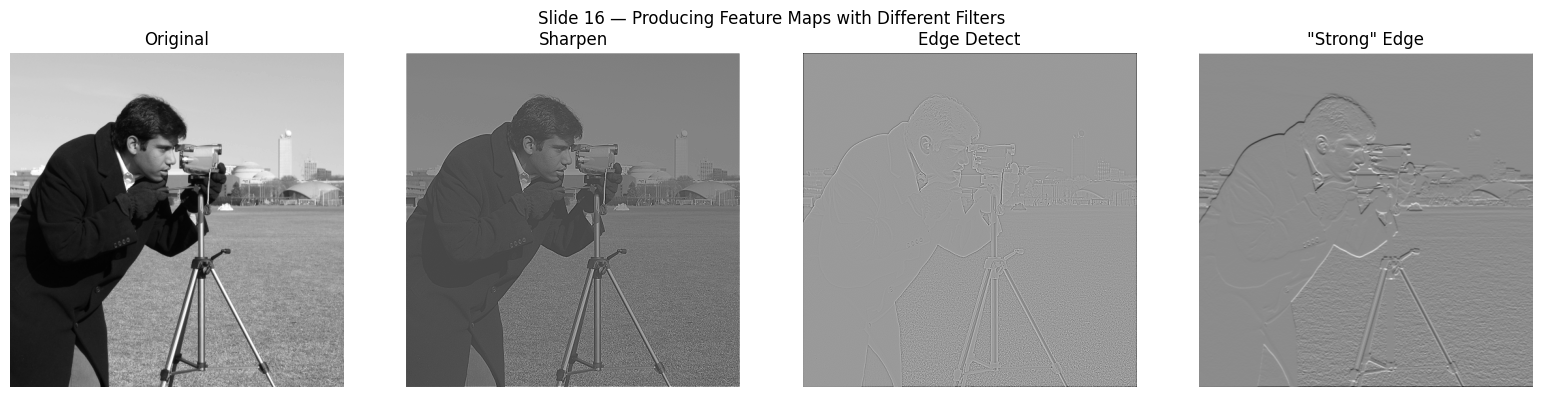

In [64]:
# Slide 16 — filters as feature detectors: sharpen vs. edge-detect kernels
img = skdata.camera().astype(float)  # built-in 512x512 grayscale test image, no download needed

kernels = {
    'Original':        np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=float),
    'Sharpen':         np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=float),
    'Edge Detect':     np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=float),
    '"Strong" Edge':   np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, k) in zip(axes, kernels.items()):
    out = conv2d_manual(img, k, padding=1)
    ax.imshow(out, cmap='gray')
    ax.set_title(name)
    ax.axis('off')
plt.suptitle('Slide 16 — Producing Feature Maps with Different Filters')
plt.tight_layout()
plt.show()


---
## §3  Multi-Channel Inputs, Padding & Stride (Slides 18–22)

- **Multi-channel** (slide 18): a filter must span the full input depth — a `3x3x3` filter on a
  `6x6x3` RGB volume collapses the channel dimension, producing a single `4x4` map.
- **Padding** (slide 19) adds a border of zeros so the output can match the input size ("same" padding).
- **Stride** (slide 20) is the filter's step size — a stride of 2 downsamples the output.
- **Output volume formula** (slides 21–22): $H' = \frac{H - K + 2P}{S} + 1$


In [65]:
# Slide 18 — multi-channel convolution: (Cin, H, W) * (Cout, Cin, kH, kW) -> (Cout, H', W')
x_rgb = torch.randn(1, 3, 6, 6)              # 1 sample, 3 channels, 6x6
conv = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3, bias=False)
out = conv(x_rgb)
print(f'Input  : {tuple(x_rgb.shape)}  (Cin=3, 6x6)')
print(f'Filter : {tuple(conv.weight.shape)}  (Cout=1, Cin=3, 3x3)')
print(f'Output : {tuple(out.shape)}  (Cout=1, 4x4)  — matches slide 18')


Input  : (1, 3, 6, 6)  (Cin=3, 6x6)
Filter : (1, 3, 3, 3)  (Cout=1, Cin=3, 3x3)
Output : (1, 1, 4, 4)  (Cout=1, 4x4)  — matches slide 18


In [66]:
# Output-size formula (slides 21-22): H' = (H - K + 2P) / S + 1
def conv_output_size(H, K, P, S):
    return (H - K + 2 * P) // S + 1

configs = [
    dict(K=3, P=1, S=1, note='3x3 conv, "same" padding'),
    dict(K=5, P=2, S=1, note='5x5 conv, "same" padding'),
    dict(K=1, P=0, S=1, note='1x1 conv (channel mixing only)'),
    dict(K=3, P=1, S=2, note='3x3 conv, downsample by 2'),
]

H_in = 32
print(f'{"K":>3} {"P":>3} {"S":>3}   formula   nn.Conv2d   note')
for c in configs:
    formula_out = conv_output_size(H_in, c['K'], c['P'], c['S'])
    layer = nn.Conv2d(3, 8, kernel_size=c['K'], padding=c['P'], stride=c['S'])
    real_out = layer(torch.randn(1, 3, H_in, H_in)).shape[-1]
    assert formula_out == real_out
    print(f'{c["K"]:>3} {c["P"]:>3} {c["S"]:>3}   {formula_out:>7}   {real_out:>9}   {c["note"]}')


  K   P   S   formula   nn.Conv2d   note
  3   1   1        32          32   3x3 conv, "same" padding
  5   2   1        32          32   5x5 conv, "same" padding
  1   0   1        32          32   1x1 conv (channel mixing only)
  3   1   2        16          16   3x3 conv, downsample by 2


In [67]:
# Slide 19 — padded convolution (zero-padding preserves a valid receptive field at the border)
img_small = skdata.camera()[:6, :6].astype(float)
kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=float)  # sharpen

no_pad = conv2d_manual(img_small, kernel, padding=0)
with_pad = conv2d_manual(img_small, kernel, padding=1)
print(f'No padding   -> output shape {no_pad.shape}  (shrinks: 6x6 -> 4x4)')
print(f'"Same" pad=1 -> output shape {with_pad.shape}  (preserved: 6x6 -> 6x6)')


No padding   -> output shape (4, 4)  (shrinks: 6x6 -> 4x4)
"Same" pad=1 -> output shape (6, 6)  (preserved: 6x6 -> 6x6)


In [68]:
# Slide 20 — strided convolution (step size > 1 downsamples the output)
x_stride_demo = torch.arange(1, 50, dtype=torch.float32).view(1, 1, 7, 7) % 5
conv_s1 = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1, bias=False)
conv_s2 = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=1, bias=False)
conv_s2.weight.data = conv_s1.weight.data  # same filter, different stride

print('stride=1 output shape:', tuple(conv_s1(x_stride_demo).shape[-2:]))
print('stride=2 output shape:', tuple(conv_s2(x_stride_demo).shape[-2:]), '(halved — downsampling)')


stride=1 output shape: (7, 7)
stride=2 output shape: (4, 4) (halved — downsampling)


---
## §4  Non-Linearity (ReLU) & Pooling (Slides 23–24)
> ReLU is applied after every conv layer: $g(z) = \max(0, z)$ — a pixel-wise non-linear operation.
> Pooling then downsamples while giving translation (spatial) invariance.


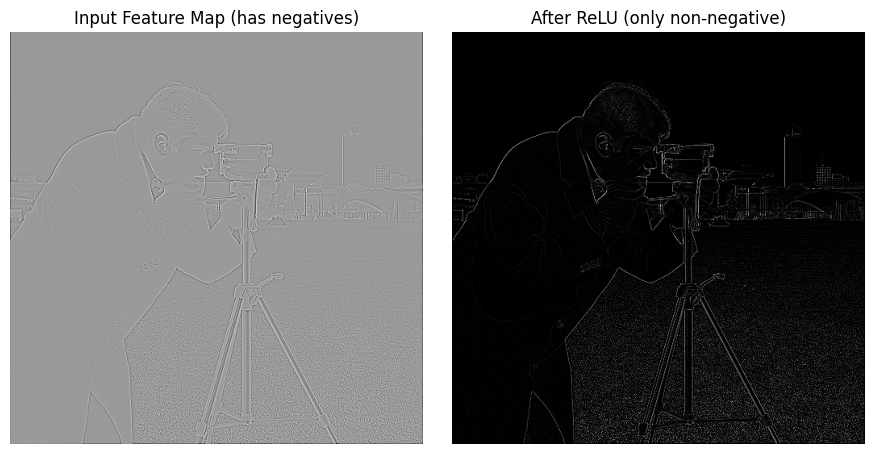

Before ReLU — min: -424.0, negative pixels: 45.3%
After  ReLU — min: 0.0, negative pixels: 0.0%


In [69]:
# Slide 23 — ReLU zeroes out negative activations (edge-detect maps have negative values)
edge_map = conv2d_manual(img, kernels['Edge Detect'], padding=1)
relu_map = np.maximum(0, edge_map)  # torch.nn.ReLU / F.relu do the same

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(edge_map, cmap='gray'); axes[0].set_title('Input Feature Map (has negatives)'); axes[0].axis('off')
axes[1].imshow(relu_map, cmap='gray'); axes[1].set_title('After ReLU (only non-negative)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

print(f'Before ReLU — min: {edge_map.min():.1f}, negative pixels: {(edge_map < 0).mean():.1%}')
print(f'After  ReLU — min: {relu_map.min():.1f}, negative pixels: {(relu_map < 0).mean():.1%}')


In [70]:
# Slide 24 — max pooling with 2x2 filter, stride 2
pool_input = torch.tensor([[1., 1., 2., 4.],
                            [5., 6., 7., 8.],
                            [3., 2., 1., 0.],
                            [1., 2., 3., 4.]]).view(1, 1, 4, 4)

maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
pooled = maxpool(pool_input)
print('Input:\n', pool_input.squeeze().numpy())
print('\nMax-pooled (2x2, stride 2) — should match slide 24 exactly [[6,8],[3,4]]:')
print(pooled.squeeze().numpy())


Input:
 [[1. 1. 2. 4.]
 [5. 6. 7. 8.]
 [3. 2. 1. 0.]
 [1. 2. 3. 4.]]

Max-pooled (2x2, stride 2) — should match slide 24 exactly [[6,8],[3,4]]:
[[6. 8.]
 [3. 4.]]


---
## §5  Multi-Filter Volumes — Manual vs. `nn.Conv2d` (Slide 25)
> The classic [cs231n interactive demo](https://cs231n.github.io/convolutional-networks/): a padded
> input volume convolved with **multiple** filters (each spanning all input channels) plus a bias,
> producing a multi-channel output volume. Let's build the general case and check it against PyTorch.


In [71]:
def conv2d_volume_manual(x, weights, biases, stride=1, padding=0):
    # x: (Cin,H,W); weights: (Cout,Cin,kH,kW); biases: (Cout,) -> (Cout,H',W')
    Cin, H, W = x.shape
    Cout, _, kH, kW = weights.shape
    if padding > 0:
        x = np.pad(x, ((0, 0), (padding, padding), (padding, padding)))
    Hp, Wp = x.shape[1], x.shape[2]
    out_h = (Hp - kH) // stride + 1
    out_w = (Wp - kW) // stride + 1
    out = np.zeros((Cout, out_h, out_w))
    for f in range(Cout):
        for i in range(out_h):
            for j in range(out_w):
                patch = x[:, i*stride:i*stride+kH, j*stride:j*stride+kW]
                out[f, i, j] = np.sum(patch * weights[f]) + biases[f]
    return out

# Random small volume matching slide 25's shapes: 7x7x3 (already-padded) input, two 3x3x3 filters, stride 2
np.random.seed(0)
x_vol = np.random.randint(-1, 2, size=(3, 7, 7)).astype(float)
W_vol = np.random.randint(-1, 2, size=(2, 3, 3, 3)).astype(float)
b_vol = np.array([1.0, 0.0])

manual_out = conv2d_volume_manual(x_vol, W_vol, b_vol, stride=2, padding=0)

conv_layer = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, stride=2, bias=True)
with torch.no_grad():
    conv_layer.weight.copy_(torch.tensor(W_vol))
    conv_layer.bias.copy_(torch.tensor(b_vol))
torch_out = conv_layer(torch.tensor(x_vol).unsqueeze(0).float()).squeeze(0).detach().numpy()

print('Manual output volume shape:', manual_out.shape, '(Cout=2, 3x3)')
print('torch  output volume shape:', torch_out.shape)
print('Max abs difference:', np.abs(manual_out - torch_out).max())
assert np.allclose(manual_out, torch_out, atol=1e-5)
print('✓ Manual multi-filter convolution matches nn.Conv2d.')


Manual output volume shape: (2, 3, 3) (Cout=2, 3x3)
torch  output volume shape: (2, 3, 3)
Max abs difference: 0.0
✓ Manual multi-filter convolution matches nn.Conv2d.


---
## §6  Counting Parameters & FLOPs (Slides 26–27)
> Input `3x32x32`, ten `5x5` filters, stride 1, pad 2 (→ output `10x32x32`).
> - **Parameters per filter** = $C_{in} \cdot K_H \cdot K_W + 1_{bias} = 3 \cdot 5 \cdot 5 + 1 = 76$
> - **Total parameters** = $10 \times 76 = 760$
> - **Multiply-adds (FLOPs)** = (parameters per filter, excluding bias) × (output positions) = $75 \times 10240 = 768{,}000$


In [72]:
layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=5, stride=1, padding=2)
n_params = sum(p.numel() for p in layer.parameters())
out_shape = layer(torch.randn(1, 3, 32, 32)).shape

params_per_filter = 3 * 5 * 5 + 1
total_params = 10 * params_per_filter
n_outputs = 10 * 32 * 32
flops = (3 * 5 * 5) * n_outputs

print(f'Output volume size        : {tuple(out_shape[1:])}')
print(f'Params per filter (calc)  : {params_per_filter}')
print(f'Total learnable params    : {total_params}  |  nn.Conv2d reports: {n_params}')
print(f'Multiply-add ops (FLOPs)  : {flops:,}')
assert n_params == total_params == 760
assert flops == 768_000


Output volume size        : (10, 32, 32)
Params per filter (calc)  : 76
Total learnable params    : 760  |  nn.Conv2d reports: 760
Multiply-add ops (FLOPs)  : 768,000


---
## §7  Transposed Convolution / Deconvolution (Slide 28)
> Transposed convolution "spreads" each input value over a kernel-sized patch of the output and sums
> overlaps — the operation used to *upsample* feature maps (used in FCNs, autoencoders, GANs).


In [73]:
deconv = nn.ConvTranspose2d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=0, bias=False)
with torch.no_grad():
    deconv.weight.fill_(1.0)  # all-ones 3x3 kernel, matching slide 28's kernel

x_in = torch.tensor([[1., 2.], [3., 4.]]).view(1, 1, 2, 2)
y_out = deconv(x_in)

print('Input (2x2):\n', x_in.squeeze().numpy())
print('\nKernel (3x3, all ones)')
print('\nOutput (4x4) — each input value is "stamped" across a 3x3 patch and overlaps are summed:')
print(y_out.squeeze().detach().numpy())
print(f'\nOutput is larger than input: {tuple(x_in.shape[-2:])} -> {tuple(y_out.shape[-2:])}')


Input (2x2):
 [[1. 2.]
 [3. 4.]]

Kernel (3x3, all ones)

Output (4x4) — each input value is "stamped" across a 3x3 patch and overlaps are summed:
[[ 1.  3.  3.  2.]
 [ 4. 10. 10.  6.]
 [ 4. 10. 10.  6.]
 [ 3.  7.  7.  4.]]

Output is larger than input: (2, 2) -> (4, 4)


---
## §8  Building & Training a Full ConvNet (Slide 29)
> `Convolution + ReLU + Pooling` blocks extract features while respecting 2D structure; a
> flatten + fully-connected head then classifies. We train this on **FashionMNIST**
> (10 classes of clothing, 28×28 grayscale).


Train subset: 6000  |  Test subset: 1500  |  Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


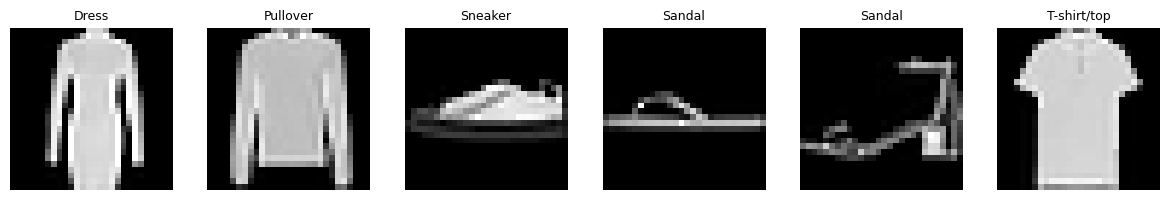

In [74]:
# Small, fast subsets so the tutorial trains in seconds, not minutes
transform = transforms.ToTensor()
train_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_full = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_ds = Subset(train_full, torch.randperm(len(train_full))[:6000])
test_ds = Subset(test_full, torch.randperm(len(test_full))[:1500])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

class_names = train_full.classes
print(f'Train subset: {len(train_ds)}  |  Test subset: {len(test_ds)}  |  Classes: {class_names}')

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for ax, (img, label) in zip(axes, [train_ds[i] for i in range(6)]):
    ax.imshow(img.squeeze(), cmap='gray'); ax.set_title(class_names[label], fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()


In [75]:
# Slide 29 — Convolution/Pooling feature-extractor + Flatten + Fully-Connected classifier
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN().to(device)
print(model)
print(f'\nTotal trainable parameters: {sum(p.numel() for p in model.parameters()):,}')


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total trainable parameters: 105,866


In [76]:
def evaluate(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_sum += F.cross_entropy(logits, y, reduction='sum').item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total

optimizer = optim.Adam(model.parameters(), lr=1e-3)
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

n_epochs = 5
for epoch in range(n_epochs):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(model, train_loader)
    val_loss, val_acc = evaluate(model, test_loader)
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}/{n_epochs} | train_loss={train_loss:.3f} acc={train_acc:.3f} '
          f'| val_loss={val_loss:.3f} acc={val_acc:.3f}')


Epoch 1/5 | train_loss=0.746 acc=0.739 | val_loss=0.807 acc=0.715
Epoch 2/5 | train_loss=0.606 acc=0.771 | val_loss=0.685 acc=0.755
Epoch 3/5 | train_loss=0.521 acc=0.811 | val_loss=0.584 acc=0.789
Epoch 4/5 | train_loss=0.458 acc=0.839 | val_loss=0.537 acc=0.815
Epoch 5/5 | train_loss=0.447 acc=0.839 | val_loss=0.526 acc=0.809


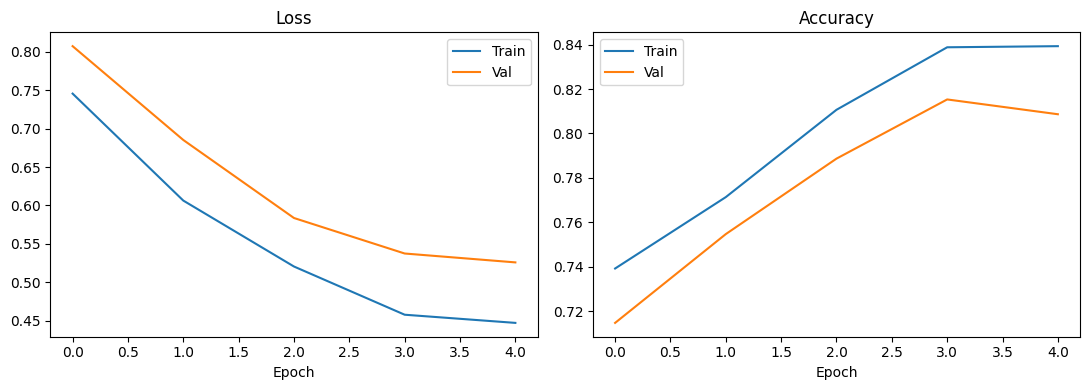

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['train_acc'], label='Train'); axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()


---
## §9  Normalization Layers (Slides 30–31)
> Different norm layers reduce statistics over different tensor axes of an `(N, C, H, W)` volume:
> - **BatchNorm** — per-channel, across the batch
> - **LayerNorm** — per-sample, across channels (+ spatial for images)
> - **InstanceNorm** — per-sample, per-channel, across spatial dims only
> - **GroupNorm** — per-sample, across a *group* of channels
>
> LayerNorm's rule (slide 31): normalize, then apply learned scale/shift — $y = \gamma \frac{x-\mu}{\sigma} + \beta$.


In [78]:
x = torch.randn(4, 8, 5, 5)  # N=4 samples, C=8 channels, 5x5 spatial

bn = nn.BatchNorm2d(8)
ln = nn.LayerNorm([8, 5, 5])
inorm = nn.InstanceNorm2d(8)
gn = nn.GroupNorm(num_groups=4, num_channels=8)

for name, layer in [('BatchNorm2d', bn), ('LayerNorm', ln), ('InstanceNorm2d', inorm), ('GroupNorm(4)', gn)]:
    out = layer(x)
    print(f'{name:>15}: output mean={out.mean().item():+.4f}, std={out.std().item():.4f}, shape={tuple(out.shape)}')


    BatchNorm2d: output mean=-0.0000, std=1.0006, shape=(4, 8, 5, 5)
      LayerNorm: output mean=+0.0000, std=1.0006, shape=(4, 8, 5, 5)
 InstanceNorm2d: output mean=+0.0000, std=1.0006, shape=(4, 8, 5, 5)
   GroupNorm(4): output mean=-0.0000, std=1.0006, shape=(4, 8, 5, 5)


In [79]:
# Slide 31 — manually reproduce LayerNorm's formula: y = gamma * (x - mu) / sigma + beta
x_ln = torch.randn(4, 10)  # (N, D)
mu = x_ln.mean(dim=1, keepdim=True)
sigma = x_ln.std(dim=1, keepdim=True, unbiased=False)
gamma, beta = torch.ones(10), torch.zeros(10)
y_manual = gamma * (x_ln - mu) / (sigma + 1e-5) + beta

y_torch = nn.LayerNorm(10)(x_ln)
print('Manual LayerNorm output (first row):\n', y_manual[0].detach().numpy().round(3))
print('\nnn.LayerNorm output   (first row):\n', y_torch[0].detach().numpy().round(3))
print('\nMax abs difference:', (y_manual - y_torch).abs().max().item())


Manual LayerNorm output (first row):
 [ 1.628  1.391  0.531  0.079 -0.477 -1.189 -0.314  0.008  0.175 -1.832]

nn.LayerNorm output   (first row):
 [ 1.628  1.391  0.531  0.079 -0.477 -1.189 -0.314  0.008  0.175 -1.832]

Max abs difference: 1.1682510375976562e-05


---
## §10  Modern CNN Architectures — VGG, ResNet, Init (Slides 32–36)


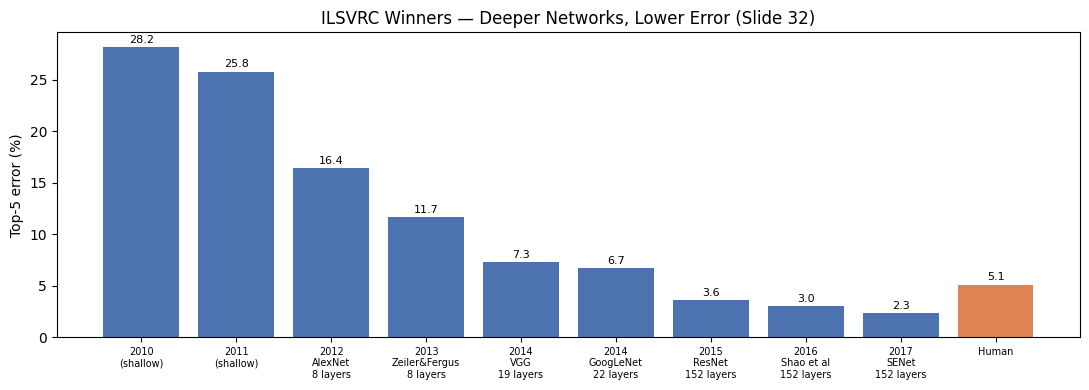

In [80]:
# Slide 32 — ILSVRC winners over the years (top-5 error %)
years =  ['2010\n(shallow)', '2011\n(shallow)', '2012\nAlexNet\n8 layers', '2013\nZeiler&Fergus\n8 layers',
          '2014\nVGG\n19 layers', '2014\nGoogLeNet\n22 layers', '2015\nResNet\n152 layers',
          '2016\nShao et al\n152 layers', '2017\nSENet\n152 layers', 'Human']
errors = [28.2, 25.8, 16.4, 11.7, 7.3, 6.7, 3.6, 3.0, 2.3, 5.1]

plt.figure(figsize=(11, 4))
bars = plt.bar(years, errors, color=['#4C72B0']*9 + ['#DD8452'])
plt.ylabel('Top-5 error (%)'); plt.title('ILSVRC Winners — Deeper Networks, Lower Error (Slide 32)')
for bar, err in zip(bars, errors):
    plt.text(bar.get_x() + bar.get_width()/2, err + 0.4, f'{err}', ha='center', fontsize=8)
plt.xticks(fontsize=7)
plt.tight_layout(); plt.show()


In [81]:
# Slide 33 — VGG's insight: stacking three 3x3 convs = same receptive field as one 7x7 conv,
# but deeper (more non-linearities) and fewer parameters.
for C in [64, 128, 256, 512]:
    params_3x3_stack = 3 * (3**2 * C**2)
    params_7x7 = 7**2 * C**2
    print(f'C={C:>3}: three 3x3 convs = {params_3x3_stack:>10,} params | one 7x7 conv = {params_7x7:>10,} params '
          f'({params_7x7/params_3x3_stack:.2f}x more)')


C= 64: three 3x3 convs =    110,592 params | one 7x7 conv =    200,704 params (1.81x more)
C=128: three 3x3 convs =    442,368 params | one 7x7 conv =    802,816 params (1.81x more)
C=256: three 3x3 convs =  1,769,472 params | one 7x7 conv =  3,211,264 params (1.81x more)
C=512: three 3x3 convs =  7,077,888 params | one 7x7 conv = 12,845,056 params (1.81x more)


In [82]:
# Slide 34-35 — ResNet's residual block: F(x) + x, solving the "going deeper" degradation problem
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        return self.relu(out + identity)     # <-- the residual (skip) connection

block = ResidualBlock(channels=16)
x = torch.randn(2, 16, 8, 8)
y = block(x)
print(f'Input shape:  {tuple(x.shape)}')
print(f'Output shape: {tuple(y.shape)}  (identity shortcut preserves shape, enabling F(x)+x)')


Input shape:  (2, 16, 8, 8)
Output shape: (2, 16, 8, 8)  (identity shortcut preserves shape, enabling F(x)+x)


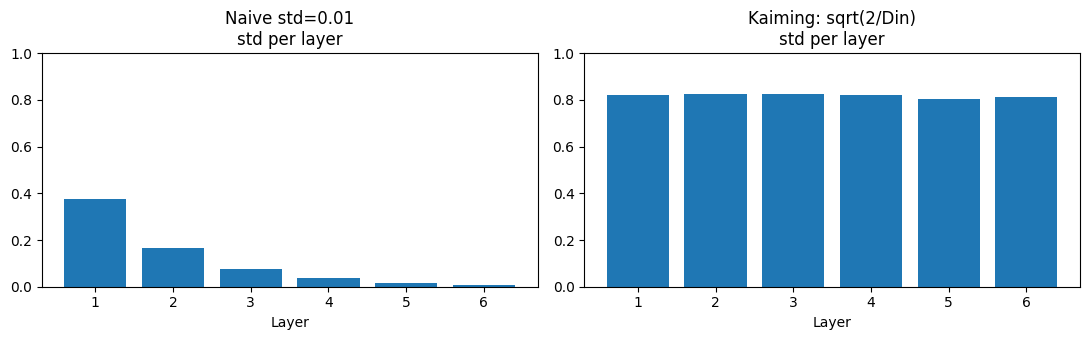

With Kaiming init, activation std stays roughly constant across layers instead of vanishing.


In [83]:
# Slide 36 — Kaiming/MSRA initialization keeps activation statistics stable across depth
def forward_pass(std_fn, n_layers=6, width=4096, n_samples=16):
    x = np.random.randn(n_samples, width)
    stats = []
    for _ in range(n_layers):
        std = std_fn(width)
        W = np.random.randn(width, width) * std
        x = np.maximum(0, x @ W)  # ReLU
        stats.append((x.mean(), x.std()))
    return stats

naive_std = lambda din: 0.01                    # too small -> activations vanish
kaiming_std = lambda din: np.sqrt(2 / din)       # He/Kaiming correction for ReLU

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (name, std_fn) in zip(axes, [('Naive std=0.01', naive_std), ('Kaiming: sqrt(2/Din)', kaiming_std)]):
    stats = forward_pass(std_fn)
    means, stds = zip(*stats)
    ax.bar(range(1, len(stats)+1), stds)
    ax.set_title(f'{name}\nstd per layer'); ax.set_xlabel('Layer'); ax.set_ylim(0, max(1.0, max(stds)*1.2))
plt.tight_layout(); plt.show()
print('With Kaiming init, activation std stays roughly constant across layers instead of vanishing.')


---
## §11  Training Recipe — Preprocessing, Augmentation, Transfer Learning, Hyperparameters (Slides 37–45)


In [84]:
# Slide 38 — image normalization: subtract per-channel mean, divide by per-channel std
sample_batch = torch.stack([train_full[i][0] for i in range(500)])  # (500, 1, 28, 28)
channel_mean = sample_batch.mean(dim=[0, 2, 3])
channel_std = sample_batch.std(dim=[0, 2, 3])
print(f'Per-channel mean: {channel_mean.tolist()}')
print(f'Per-channel std : {channel_std.tolist()}')

normalize = transforms.Normalize(mean=channel_mean.tolist(), std=channel_std.tolist())
normalized = normalize(sample_batch[0])
print(f'\nBefore normalization -> mean={sample_batch[0].mean():.3f}, std={sample_batch[0].std():.3f}')
print(f'After  normalization -> mean={normalized.mean():.3f}, std={normalized.std():.3f}')


Per-channel mean: [0.2837960124015808]
Per-channel std : [0.3520340919494629]

Before normalization -> mean=0.381, std=0.399
After  normalization -> mean=0.277, std=1.135


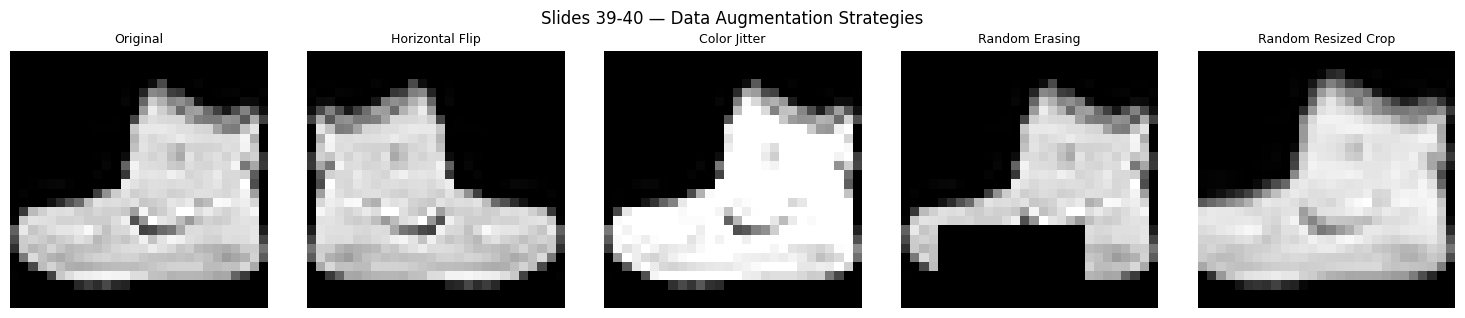

In [85]:
# Slides 39-40 — data augmentation: flips, color jitter, random erasing (cutout), random-resized crop
img_pil = torchvision.transforms.functional.to_pil_image(train_full[0][0])

augmentations = {
    'Original': transforms.Compose([]),
    'Horizontal Flip': transforms.RandomHorizontalFlip(p=1.0),
    'Color Jitter': transforms.ColorJitter(brightness=0.5, contrast=0.5),
    'Random Erasing': transforms.Compose([transforms.ToTensor(), transforms.RandomErasing(p=1.0, scale=(0.1, 0.2)), transforms.ToPILImage()]),
    'Random Resized Crop': transforms.RandomResizedCrop(28, scale=(0.6, 1.0)),
}

fig, axes = plt.subplots(1, len(augmentations), figsize=(15, 3.2))
for ax, (name, aug) in zip(axes, augmentations.items()):
    out_img = aug(img_pil)
    ax.imshow(out_img, cmap='gray'); ax.set_title(name, fontsize=9); ax.axis('off')
plt.suptitle('Slides 39-40 — Data Augmentation Strategies')
plt.tight_layout(); plt.show()


In [86]:
# Slides 41-42 — transfer learning: freeze a pretrained backbone, replace + train the head
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet.parameters():
    param.requires_grad = False               # freeze the pretrained backbone

num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 4)             # reinitialize the head for a new 4-class task

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in resnet.parameters() if not p.requires_grad)
print(f'Frozen (pretrained) params : {frozen:,}')
print(f'Trainable (new head) params: {trainable:,}')
print('\nSlide 42 decision table:')
print(' - very little data, similar domain -> linear probe on frozen features (this cell)')
print(' - lots of data, similar domain     -> unfreeze & fine-tune all layers')
print(' - very different domain            -> fine-tune all layers, or train from scratch')


Frozen (pretrained) params : 11,176,512
Trainable (new head) params: 2,052

Slide 42 decision table:
 - very little data, similar domain -> linear probe on frozen features (this cell)
 - lots of data, similar domain     -> unfreeze & fine-tune all layers
 - very different domain            -> fine-tune all layers, or train from scratch


In [87]:
# Quick end-to-end check: fine-tune only the new head on a tiny CIFAR-10 subset (4 classes)
cifar_transform = transforms.Compose([
    transforms.Resize(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)

wanted_classes = [0, 1, 8, 9]  # airplane, automobile, ship, truck
idx = [i for i, (_, y) in enumerate(cifar_train) if y in wanted_classes][:400]
remap = {c: i for i, c in enumerate(wanted_classes)}

class RemappedSubset(torch.utils.data.Dataset):
    def __init__(self, ds, indices, remap):
        self.ds, self.indices, self.remap = ds, indices, remap
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        x, y = self.ds[self.indices[i]]
        return x, self.remap[y]

tl_ds = RemappedSubset(cifar_train, idx, remap)
tl_loader = DataLoader(tl_ds, batch_size=32, shuffle=True)

resnet = resnet.to(device)
optimizer = optim.Adam(resnet.fc.parameters(), lr=1e-3)  # only the head has requires_grad=True

resnet.train()
for epoch in range(2):
    total_loss, correct, total = 0.0, 0, 0
    for x, y in tl_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = resnet(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    print(f'Epoch {epoch+1}: loss={total_loss/total:.3f}, acc={correct/total:.3f}  (frozen ResNet18 backbone, new head only)')


Using downloaded and verified file: ./data/cifar-10-python.tar.gz
Extracting ./data/cifar-10-python.tar.gz to ./data
Epoch 1: loss=1.432, acc=0.282  (frozen ResNet18 backbone, new head only)
Epoch 2: loss=1.119, acc=0.570  (frozen ResNet18 backbone, new head only)


In [88]:
# Slides 43-45 — choosing hyperparameters
# Step 1: sanity-check the initial loss for an untrained classifier
sanity_model = SimpleCNN().to(device)
x0, y0 = next(iter(train_loader))
initial_loss = F.cross_entropy(sanity_model(x0.to(device)), y0.to(device)).item()
expected_loss = -np.log(1 / 10)  # 10 balanced classes, random guessing
print(f'Step 1 — Initial loss: {initial_loss:.3f}  (expected ~{expected_loss:.3f} for 10-class random guessing)')


Step 1 — Initial loss: 2.307  (expected ~2.303 for 10-class random guessing)


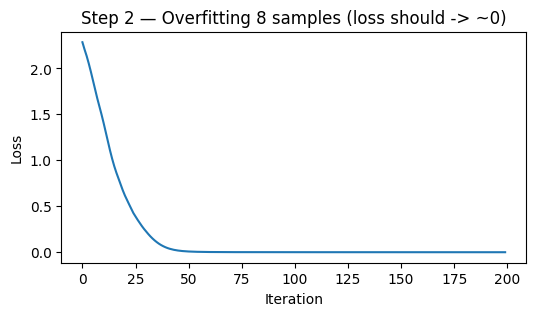

Final loss on tiny sample: 0.0002


In [89]:
# Step 2: overfit a tiny sample (proves the model + optimizer can memorize)
tiny_x, tiny_y = x0[:8].to(device), y0[:8].to(device)
overfit_model = SimpleCNN().to(device)
opt = optim.Adam(overfit_model.parameters(), lr=1e-3)

losses = []
for step in range(200):
    opt.zero_grad()
    loss = F.cross_entropy(overfit_model(tiny_x), tiny_y)
    loss.backward(); opt.step()
    losses.append(loss.item())

plt.figure(figsize=(6, 3)); plt.plot(losses)
plt.title('Step 2 — Overfitting 8 samples (loss should -> ~0)'); plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.show()
print(f'Final loss on tiny sample: {losses[-1]:.4f}')


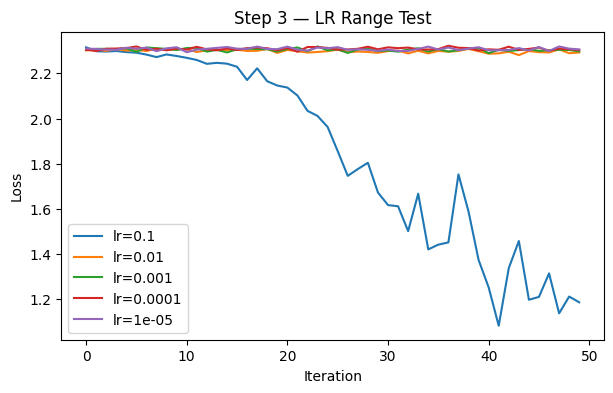

In [90]:
# Step 3: learning-rate range test — find an LR that makes the loss drop within ~100 iterations
lrs_to_try = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
plt.figure(figsize=(7, 4))
for lr in lrs_to_try:
    m = SimpleCNN().to(device)
    opt = optim.SGD(m.parameters(), lr=lr, weight_decay=1e-4)
    losses = []
    it = iter(train_loader)
    for _ in range(50):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(train_loader); x, y = next(it)
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = F.cross_entropy(m(x), y)
        loss.backward(); opt.step()
        losses.append(loss.item())
    plt.plot(losses, label=f'lr={lr}')
plt.legend(); plt.title('Step 3 — LR Range Test'); plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.show()


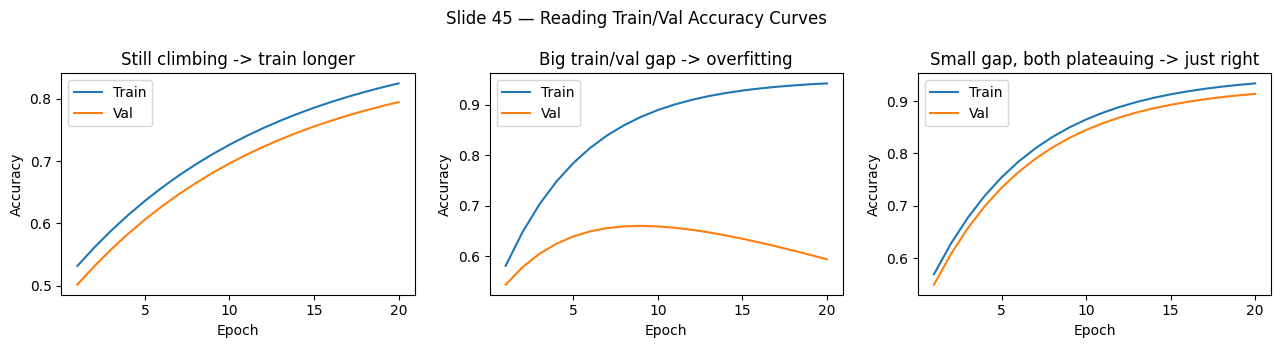

In [91]:
# Step 6 — reading loss/accuracy curves (slide 45): underfit / overfit / just-right patterns
epochs = np.arange(1, 21)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

train_underfit = 0.5 + 0.4 * (1 - np.exp(-epochs/12)); val_underfit = train_underfit - 0.03
axes[0].plot(epochs, train_underfit, label='Train'); axes[0].plot(epochs, val_underfit, label='Val')
axes[0].set_title('Still climbing -> train longer')

train_overfit = 0.5 + 0.45 * (1 - np.exp(-epochs/5))
val_overfit = 0.5 + 0.3 * (1 - np.exp(-epochs/5)) - 0.01 * epochs
axes[1].plot(epochs, train_overfit, label='Train'); axes[1].plot(epochs, val_overfit, label='Val')
axes[1].set_title('Big train/val gap -> overfitting')

train_ok = 0.5 + 0.45 * (1 - np.exp(-epochs/6)); val_ok = train_ok - 0.02
axes[2].plot(epochs, train_ok, label='Train'); axes[2].plot(epochs, val_ok, label='Val')
axes[2].set_title('Small gap, both plateauing -> just right')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.legend()
plt.suptitle('Slide 45 — Reading Train/Val Accuracy Curves')
plt.tight_layout(); plt.show()


---
## §12  CNN Applications (Slides 46–54)

The feature-extraction backbone from §8 is reused across many vision tasks by swapping the head:

| Task | Head on top of conv features | Example (slide) |
|------|-------------------------------|------------------|
| Classification | Softmax over classes | Breast-cancer screening (47) |
| Object detection | Region proposals + per-region classifier & box regressor (Faster R-CNN) | Taxi/person/truck boxes (48–50) |
| Semantic segmentation | Downsample then **upsample** (transposed conv) back to `HxW` | Cow segmentation, FCN (51) |
| Autoencoding | Encoder (conv, downsample) + Decoder (deconv, upsample), no labels needed | MNIST reconstruction (52) |
| Control | Conv features -> probabilistic / deterministic outputs | End-to-end driving (53) |
| CRNN (OCR) | Conv features -> **bidirectional LSTM** -> per-frame character distribution | Reading "STATE" (54) — this is where §12 meets the RNN tutorial! |

Detection and segmentation need specialized datasets (COCO, Cityscapes) and models
(`torchvision.models.detection.fasterrcnn_resnet50_fpn`, `torchvision.models.segmentation.fcn_resnet50`) —
out of scope for this tutorial, but they reuse every building block from §2–§10.
The **autoencoder** (slide 52), however, is fully self-contained — let's build one on FashionMNIST.


In [92]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),   # 28x28 -> 14x14
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),  # 14x14 -> 7x7
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 7x7 -> 14x14
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid(), # 14x14 -> 28x28
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

ae = ConvAutoencoder().to(device)
opt = optim.Adam(ae.parameters(), lr=1e-3)

for epoch in range(3):
    total_loss = 0.0
    for x, _ in train_loader:
        x = x.to(device)
        opt.zero_grad()
        recon = ae(x)
        loss = F.mse_loss(recon, x)
        loss.backward(); opt.step()
        total_loss += loss.item() * x.size(0)
    print(f'Epoch {epoch+1}: reconstruction MSE = {total_loss/len(train_ds):.4f}')


Epoch 1: reconstruction MSE = 0.1475
Epoch 2: reconstruction MSE = 0.0545
Epoch 3: reconstruction MSE = 0.0220


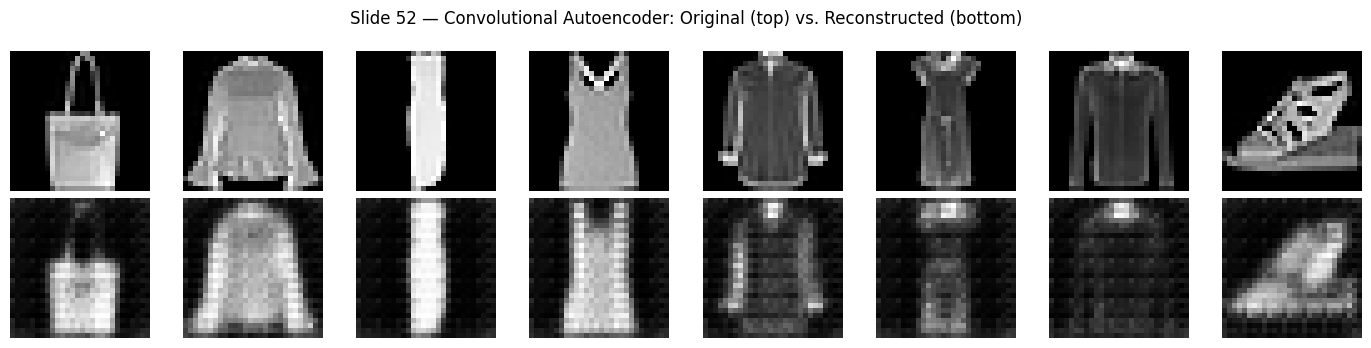

In [93]:
ae.eval()
x_sample, _ = next(iter(test_loader))
x_sample = x_sample[:8].to(device)
with torch.no_grad():
    recon_sample = ae(x_sample)

fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
for i in range(8):
    axes[0, i].imshow(x_sample[i].cpu().squeeze(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon_sample[i].cpu().squeeze(), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
plt.suptitle('Slide 52 — Convolutional Autoencoder: Original (top) vs. Reconstructed (bottom)')
plt.tight_layout(); plt.show()


---
## Recap

We went from a single Hadamard-product neuron (slide 8) all the way to a trained ConvNet,
a fine-tuned ResNet, and a working convolutional autoencoder — reproducing every core idea in the
lecture's CNN section (slides 1–54) with runnable, verified code.

**Next:** `Module_1_RNN_Tutorial.ipynb` picks up at "Sequential Modelling" (slide 55) and builds
recurrent networks from the same first-principles approach.
